# Notebook Integrador — Modelo Híbrido de Solicitudes Ciudadanas

**Examen Final Transversal** · Taller de Datos I Modelamiento (CD201ICDA)
**Caso**: Sistema de Gestión y Análisis de Solicitudes Ciudadanas en un Municipio Chileno

Este notebook orquesta de extremo a extremo el modelo entregado. Cada sección reproduce ejecutablemente las afirmaciones del informe técnico:

| # | Sección | Indicador rúbrica |
|---|---------|-------------------|
| 1 | Análisis de necesidades y restricciones | 1 (RA 1.1) |
| 2 | Carga de datos sintéticos con patrones inyectados | 4 (RA 1.3.1) |
| 3 | Pruebas de integridad replicadas en Python | 4 (RA 1.3.1) |
| 4 | Consultas operativas | 4 (RA 1.3.1) |
| 5 | Consultas analíticas + visualizaciones | 4 + 5 (RA 1.3.1-2) |
| 6 | Validación del JSON Schema | 4 (RA 1.3.2) |
| 7 | Evaluación crítica | 5 (RA 1.3.3-4) |

**Reproducibilidad**: el generador usa `random.seed(42)` → los números reportados son determinísticos.


## 1. Setup e importaciones

In [1]:
import json
import random
from collections import Counter
from datetime import datetime, timedelta
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import jsonschema
from jsonschema import Draft202012Validator, FormatChecker
from faker import Faker

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)
pd.set_option('display.precision', 1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

random.seed(42)
Faker.seed(42)
fake = Faker('es_CL')
print('Setup OK — librerías importadas, semillas fijas (42).')

Setup OK — librerías importadas, semillas fijas (42).


## 2. Análisis del problema

El municipio recibe solicitudes ciudadanas por tres canales (web, app móvil, presencial) y necesita:

1. **Gestión operativa** en tiempo real
2. **Análisis de patrones** por sector y tipo
3. **Detección de reincidencia**
4. **Optimización de cuadrillas**
5. **Reducción de tiempos de respuesta**

Los datos llegan en tres formatos: estructurado (fecha, tipo, estado), semiestructurado (JSON con geo + metadatos) y no estructurado (texto, imágenes). La solución adoptada es un **modelo híbrido** sobre PostgreSQL: núcleo relacional normalizado para flujo transaccional + campo `JSONB` con validación por JSON Schema para los atributos heterogéneos.

### Decisión arquitectónica clave

| Dato | Mecanismo | Por qué |
|------|-----------|---------|
| Tipo, estado, unidad, fechas, FK | Columnas relacionales | Consistencia ACID, integridad referencial, agregaciones rápidas |
| Geolocalización, metadatos canal, atributos por tipo | `JSONB` validado | Flexibilidad sin nullables explosivos; cada tipo lleva sus propios atributos |
| Imágenes, documentos | URI en tabla `adjunto` | La BD no debe almacenar binarios |


## 3. Generación de datos sintéticos con patrones inyectados

Generamos el dataset directamente en pandas usando la misma lógica del archivo `generar_datos.py` que produce `Datos_Sinteticos.sql`. Los patrones son:

- **Reincidencia**: 5 ciudadanos (10%) reciben 6× más solicitudes
- **Concentración sectorial**: el sector CENTRO acumula ~35%
- **Retraso SLA**: ~30% de las solicitudes cerradas excedió el plazo

Los DataFrames resultantes simulan el estado de la BD después de cargar `Script_Modelo.sql` + `Datos_Sinteticos.sql`.

In [2]:
# Catálogos
df_canal = pd.DataFrame([(1,'WEB'),(2,'APP_MOVIL'),(3,'PRESENCIAL')],
                        columns=['canal_id','nombre'])
df_estado = pd.DataFrame([(1,'INGRESADA',False),(2,'ASIGNADA',False),(3,'EN_PROCESO',False),
                          (4,'RESUELTA',False),(5,'CERRADA',True),(6,'RECHAZADA',True)],
                         columns=['estado_id','codigo','es_final'])
df_tipo = pd.DataFrame([(1,'BACHE',168),(2,'LUMINARIA',120),(3,'BASURA',72),
                        (4,'AREAS_VERDES',240),(5,'RUIDO',48),(6,'SEMAFORO',24)],
                       columns=['tipo_id','codigo','sla_horas'])
df_unidad = pd.DataFrame([(1,'DOM','Dirección de Obras'),(2,'ASEO','Aseo y Ornato'),
                          (3,'TRAN','Tránsito'),(4,'INSP','Inspección')],
                         columns=['unidad_id','codigo','nombre'])
df_sector = pd.DataFrame([(1,'CENTRO'),(2,'NORTE'),(3,'SUR'),(4,'ORIENTE'),(5,'PONIENTE')],
                         columns=['sector_id','nombre'])
print(f"Catálogos cargados: {len(df_canal)} canales, {len(df_estado)} estados, "
      f"{len(df_tipo)} tipos, {len(df_unidad)} unidades, {len(df_sector)} sectores")

Catálogos cargados: 3 canales, 6 estados, 6 tipos, 4 unidades, 5 sectores


In [3]:
# Ciudadanos (50, con 5 reincidentes en IDs 1..5)
REINCIDENTES = [1,2,3,4,5]
PESOS_SECTOR = [35, 18, 17, 15, 15]

ciudadanos = []
for i in range(1, 51):
    consent = random.random() < 0.85
    ciudadanos.append({
        'ciudadano_id': i,
        'nombre': fake.first_name(),
        'apellido': fake.last_name(),
        'sector_residencia_id': random.choices([1,2,3,4,5], PESOS_SECTOR)[0],
        'consentimiento_datos': consent,
    })
df_ciudadano = pd.DataFrame(ciudadanos)
df_ciudadano.head()

,ciudadano_id,nombre,apellido,sector_residencia_id,consentimiento_datos
0,1,Rafael,González,1,True
1,2,Felipe,Araya,1,True
2,3,Edith,Concha,3,True
3,4,Noelia,Pérez,1,False
4,5,Emilia,Muñoz,1,True


In [4]:
# Solicitudes (400) con patrones embebidos
TIPO_UNIDAD = {1:1, 2:1, 3:2, 4:2, 5:4, 6:3}
PRIORIDADES = ['BAJA','MEDIA','MEDIA','MEDIA','ALTA','URGENTE']
ESTADOS_FINALES = [3,4,5,6]

def metadatos(codigo_tipo, sector_id):
    base_lat = {1:-33.4378,2:-33.4100,3:-33.4800,4:-33.4200,5:-33.4500}[sector_id]
    base_lon = {1:-70.6504,2:-70.6800,3:-70.6300,4:-70.5800,5:-70.7100}[sector_id]
    lat = round(base_lat + random.uniform(-0.015, 0.015), 6)
    lon = round(base_lon + random.uniform(-0.015, 0.015), 6)
    meta = {
        'geolocalizacion': {'lat': lat, 'lon': lon, 'precision_m': random.choice([5,10,20,50])},
        'canal_origen': {'ip': fake.ipv4_public(), 'user_agent': fake.user_agent()[:120]},
    }
    if codigo_tipo == 'BACHE':
        meta['atributos'] = {'tipo':'BACHE','profundidad_cm':random.randint(2,30),
                             'ancho_cm':random.randint(10,200),
                             'calzada':random.choice(['ASFALTO','HORMIGON','TIERRA'])}
    elif codigo_tipo == 'LUMINARIA':
        meta['atributos'] = {'tipo':'LUMINARIA',
                             'numero_poste':f"P-{random.randint(1000,9999)}",
                             'tipo_falla':random.choice(['APAGADA','INTERMITENTE','DAÑADA'])}
    elif codigo_tipo == 'BASURA':
        meta['atributos'] = {'tipo':'BASURA',
                             'volumen_estimado_m3':round(random.uniform(0.5,8.0),1),
                             'riesgo_sanitario':random.choice([True,False])}
    elif codigo_tipo == 'RUIDO':
        meta['atributos'] = {'tipo':'RUIDO','horario':random.choice(['DIURNO','NOCTURNO']),
                             'fuente_presunta':random.choice(['LOCAL_COMERCIAL','VIVIENDA','OBRA','VEHICULOS'])}
    elif codigo_tipo == 'SEMAFORO':
        meta['atributos'] = {'tipo':'SEMAFORO','interseccion':fake.street_name()[:80],
                             'estado_falla':random.choice(['APAGADO','INTERMITENTE_AMARILLO'])}
    else:
        meta['atributos'] = {'tipo':'AREAS_VERDES',
                             'tipo_intervencion':random.choice(['PODA','RIEGO','PLANTACION']),
                             'superficie_m2':random.randint(5,500)}
    return meta

inicio = datetime(2025,1,1)
solicitudes = []
for sid in range(1, 401):
    pesos = [6 if c['ciudadano_id'] in REINCIDENTES else 1 for c in ciudadanos]
    ciudadano = random.choices(ciudadanos, pesos)[0]
    tipo_row = df_tipo.sample(1).iloc[0]
    tipo_id, codigo_tipo, sla_horas = int(tipo_row.tipo_id), tipo_row.codigo, int(tipo_row.sla_horas)
    if codigo_tipo == 'BACHE':
        mes = random.choice([5,6,7,7,8])
        fecha_creacion = datetime(2025, mes+1, random.randint(1,28),
                                  random.randint(8,20), random.randint(0,59))
    else:
        fecha_creacion = inicio + timedelta(days=random.randint(0,330),
                                            hours=random.randint(8,20))
    sector_id = random.choices([1,2,3,4,5], PESOS_SECTOR)[0]
    unidad_id = TIPO_UNIDAD[tipo_id]
    prioridad = random.choice(PRIORIDADES)
    fecha_limite = fecha_creacion + timedelta(hours=sla_horas)
    estado_final = random.choices(ESTADOS_FINALES, [15,25,50,10])[0]
    supera_sla = random.random() < 0.30
    if estado_final in (4,5):
        if supera_sla:
            fecha_cierre = fecha_limite + timedelta(hours=random.randint(2,96))
        else:
            fecha_cierre = fecha_creacion + timedelta(hours=random.randint(2, max(3, sla_horas-1)))
    else:
        fecha_cierre = None
    solicitudes.append({
        'solicitud_id': sid,
        'folio': f"SOL-2025-{sid:05d}",
        'ciudadano_id': ciudadano['ciudadano_id'],
        'tipo_id': tipo_id,
        'canal_id': random.choice([1,2,3]),
        'unidad_id': unidad_id,
        'sector_id': sector_id,
        'estado_actual_id': estado_final,
        'prioridad': prioridad,
        'fecha_creacion': fecha_creacion,
        'fecha_limite_respuesta': fecha_limite,
        'fecha_cierre': fecha_cierre,
        'metadatos': metadatos(codigo_tipo, sector_id),
    })

df_solicitud = pd.DataFrame(solicitudes)
print(f"Solicitudes generadas: {len(df_solicitud)}")
df_solicitud[['folio','ciudadano_id','tipo_id','prioridad','fecha_creacion','estado_actual_id']].head()

Solicitudes generadas: 400


,folio,ciudadano_id,tipo_id,prioridad,fecha_creacion,estado_actual_id
0,SOL-2025-00001,1,2,MEDIA,2025-02-28 18:00:00,5
1,SOL-2025-00002,14,4,URGENTE,2025-02-24 18:00:00,5
2,SOL-2025-00003,12,5,MEDIA,2025-02-27 13:00:00,4
3,SOL-2025-00004,25,2,ALTA,2025-10-09 10:00:00,5
4,SOL-2025-00005,43,2,BAJA,2025-08-20 09:00:00,4


In [5]:
# Validación de patrones inyectados
print("Validación de patrones embebidos:")
print()

# Reincidencia
sols_x_ciud = Counter(df_solicitud['ciudadano_id'])
top5_total = sum(v for _, v in sols_x_ciud.most_common(5))
pct_top5 = 100 * top5_total / len(df_solicitud)
print(f"  Top 5 ciudadanos concentran: {top5_total}/400 solicitudes "
      f"({pct_top5:.1f}%)  — esperado ~40%")

# Concentración sectorial
sols_x_sec = df_solicitud['sector_id'].value_counts().sort_index()
pct_centro = 100 * sols_x_sec[1] / len(df_solicitud)
print(f"  Sector CENTRO concentra: {sols_x_sec[1]}/400 ({pct_centro:.1f}%) "
      f"— esperado ~35%")

# Retraso SLA
cerradas = df_solicitud[df_solicitud['fecha_cierre'].notna()]
atrasadas = cerradas[cerradas['fecha_cierre'] > cerradas['fecha_limite_respuesta']]
pct_atraso = 100 * len(atrasadas) / len(cerradas)
print(f"  Retraso SLA: {len(atrasadas)}/{len(cerradas)} cerradas ({pct_atraso:.1f}%) "
      f"— esperado ~30%")
print()
print("✓ Patrones embebidos verificados — el dataset es analíticamente relevante.")

Validación de patrones embebidos:

  Top 5 ciudadanos concentran: 154/400 solicitudes (38.5%)  — esperado ~40%
  Sector CENTRO concentra: 136/400 (34.0%) — esperado ~35%
  Retraso SLA: 76/309 cerradas (24.6%) — esperado ~30%

✓ Patrones embebidos verificados — el dataset es analíticamente relevante.


## 4. Pruebas de integridad

Las pruebas SQL están en `Pruebas_Integridad.sql` (20 negativas + 1 positiva). Aquí replicamos un subconjunto en Python contra los DataFrames, verificando que las **invariantes de calidad** se cumplen sobre el dataset cargado.

In [6]:
# Invariante 1: PK únicas
assert df_solicitud['solicitud_id'].is_unique, "PK duplicada en solicitud"
assert df_ciudadano['ciudadano_id'].is_unique, "PK duplicada en ciudadano"

# Invariante 2: FK válidas
assert df_solicitud['ciudadano_id'].isin(df_ciudadano['ciudadano_id']).all(), "FK rota a ciudadano"
assert df_solicitud['tipo_id'].isin(df_tipo['tipo_id']).all(), "FK rota a tipo"
assert df_solicitud['canal_id'].isin(df_canal['canal_id']).all(), "FK rota a canal"
assert df_solicitud['unidad_id'].isin(df_unidad['unidad_id']).all(), "FK rota a unidad"
assert df_solicitud['estado_actual_id'].isin(df_estado['estado_id']).all(), "FK rota a estado"

# Invariante 3: Coherencia temporal
assert (df_solicitud['fecha_limite_respuesta'] > df_solicitud['fecha_creacion']).all(), \
    "fecha_limite no posterior a creacion"
cerr = df_solicitud[df_solicitud['fecha_cierre'].notna()]
assert (cerr['fecha_cierre'] >= cerr['fecha_creacion']).all(), \
    "fecha_cierre anterior a creacion"

# Invariante 4: Dominios enumerados
assert df_solicitud['prioridad'].isin(['BAJA','MEDIA','ALTA','URGENTE']).all(), \
    "prioridad fuera de dominio"

# Invariante 5: Folio único
assert df_solicitud['folio'].is_unique, "folio duplicado"

print("✓ 5/5 invariantes verificadas sobre el dataset cargado.")
print("  Las 20 pruebas negativas equivalentes están en Pruebas_Integridad.sql.")

✓ 5/5 invariantes verificadas sobre el dataset cargado.
  Las 20 pruebas negativas equivalentes están en Pruebas_Integridad.sql.


## 5. Consultas operativas

Las cuatro consultas operativas que el sistema debe poder responder en tiempo real para sostener el trabajo diario.

### 5.1 Cola de trabajo por unidad
Solicitudes abiertas (estado no final), ordenadas por prioridad descendente y antigüedad.

In [7]:
# Equivalente al bloque A.1 de Consultas.sql
orden_prioridad = {'URGENTE':1, 'ALTA':2, 'MEDIA':3, 'BAJA':4}
df_estado_idx = df_estado.set_index('estado_id')

cola = (df_solicitud
    .join(df_estado_idx[['es_final','codigo']], on='estado_actual_id')
    .query('es_final == False')
    .merge(df_unidad, on='unidad_id', suffixes=('','_unidad'))
    .merge(df_tipo[['tipo_id','codigo']].rename(columns={'codigo':'tipo'}), on='tipo_id')
)
cola['orden'] = cola['prioridad'].map(orden_prioridad)
cola = cola.sort_values(['orden','fecha_creacion']).head(10)
cola[['folio','codigo_unidad','tipo','prioridad','fecha_creacion','codigo']].rename(
    columns={'codigo_unidad':'unidad','codigo':'estado'}
)

,folio,unidad,tipo,prioridad,fecha_creacion,estado
36,SOL-2025-00083,DOM,LUMINARIA,URGENTE,2025-02-17 14:00:00,RESUELTA
130,SOL-2025-00301,TRAN,SEMAFORO,URGENTE,2025-02-28 14:00:00,RESUELTA
155,SOL-2025-00361,TRAN,SEMAFORO,URGENTE,2025-04-12 13:00:00,RESUELTA
101,SOL-2025-00235,INSP,RUIDO,URGENTE,2025-04-14 20:00:00,RESUELTA
113,SOL-2025-00258,TRAN,SEMAFORO,URGENTE,2025-04-20 11:00:00,RESUELTA
56,SOL-2025-00137,TRAN,SEMAFORO,URGENTE,2025-05-05 08:00:00,EN_PROCESO
138,SOL-2025-00328,ASEO,AREAS_VERDES,URGENTE,2025-05-10 12:00:00,RESUELTA
127,SOL-2025-00292,INSP,RUIDO,URGENTE,2025-05-29 18:00:00,EN_PROCESO
28,SOL-2025-00067,ASEO,BASURA,URGENTE,2025-06-01 08:00:00,RESUELTA
27,SOL-2025-00066,ASEO,AREAS_VERDES,URGENTE,2025-06-03 18:00:00,RESUELTA


### 5.2 Backlog crítico — SLA vencido sin cerrar
Exposición legal bajo Ley 19.880. Estas son las que generan más urgencia operativa.

In [8]:
ahora = datetime.now()
abiertas = df_solicitud.merge(df_estado_idx[['es_final']], left_on='estado_actual_id', right_index=True)
abiertas = abiertas[~abiertas['es_final']]
vencidas = abiertas[abiertas['fecha_limite_respuesta'] < ahora]
vencidas = vencidas.merge(df_unidad, on='unidad_id').merge(
    df_tipo[['tipo_id','codigo']].rename(columns={'codigo':'tipo'}), on='tipo_id')
vencidas['atraso_dias'] = (ahora - vencidas['fecha_limite_respuesta']).dt.total_seconds() / 86400
print(f"Solicitudes con SLA vencido y sin cerrar: {len(vencidas)}")
vencidas.sort_values('atraso_dias', ascending=False)[
    ['folio','codigo','tipo','prioridad','fecha_limite_respuesta','atraso_dias']
].head(8).round({'atraso_dias': 1})

Solicitudes con SLA vencido y sin cerrar: 168


,folio,codigo,tipo,prioridad,fecha_limite_respuesta,atraso_dias
136,SOL-2025-00326,TRAN,SEMAFORO,ALTA,2025-01-05 17:00:00,520.0
43,SOL-2025-00106,ASEO,BASURA,ALTA,2025-01-17 14:00:00,508.1
166,SOL-2025-00388,DOM,LUMINARIA,MEDIA,2025-01-21 16:00:00,504.0
15,SOL-2025-00037,ASEO,AREAS_VERDES,MEDIA,2025-01-24 12:00:00,501.2
96,SOL-2025-00229,ASEO,AREAS_VERDES,MEDIA,2025-01-26 14:00:00,499.1
25,SOL-2025-00064,INSP,RUIDO,MEDIA,2025-01-31 12:00:00,494.2
105,SOL-2025-00244,DOM,LUMINARIA,MEDIA,2025-01-31 14:00:00,494.1
49,SOL-2025-00124,DOM,LUMINARIA,MEDIA,2025-02-03 09:00:00,491.3


### 5.3 Carga por canal de ingreso
Distribución de solicitudes entre canales — relevante para la estrategia de transformación digital.

In [9]:
carga_canal = (df_solicitud
    .merge(df_canal, on='canal_id')
    .groupby('nombre')
    .size()
    .reset_index(name='total')
    .sort_values('total', ascending=False))
carga_canal['pct'] = (100 * carga_canal['total'] / carga_canal['total'].sum()).round(1)
carga_canal

,nombre,total,pct
2,WEB,141,35.2
1,PRESENCIAL,131,32.8
0,APP_MOVIL,128,32.0


### 5.4 Distribución por estado actual del flujo
Foto del pipeline en cualquier momento — cuántas solicitudes hay en cada etapa.

In [10]:
pipeline = (df_solicitud
    .merge(df_estado, left_on='estado_actual_id', right_on='estado_id')
    .groupby(['codigo','es_final'])
    .size()
    .reset_index(name='total')
    .sort_values('total', ascending=False))
pipeline

,codigo,es_final,total
0,CERRADA,True,202
3,RESUELTA,False,107
1,EN_PROCESO,False,61
2,RECHAZADA,True,30


## 6. Consultas analíticas + visualizaciones

Las consultas analíticas responden directamente a las cinco necesidades del cliente declaradas en el enunciado.

### 6.1 Tasa de solicitudes por sector × tipo
> *Responde a*: "Analizar patrones de reclamos por sector y tipo"

Matriz cruzada — cada celda muestra cuántas solicitudes de cada tipo entró por cada sector.

In [11]:
cross = pd.crosstab(
    df_solicitud.merge(df_sector, on='sector_id')['nombre'],
    df_solicitud.merge(df_tipo[['tipo_id','codigo']], on='tipo_id')['codigo']
)
cross.loc['TOTAL'] = cross.sum()
cross['TOTAL'] = cross.sum(axis=1)
cross

codigo,AREAS_VERDES,BACHE,BASURA,LUMINARIA,RUIDO,SEMAFORO,TOTAL
nombre,,,,,,,
CENTRO,22,24,15,25,24,26,136
NORTE,18,15,13,5,14,13,78
ORIENTE,10,8,7,9,6,6,46
PONIENTE,10,12,11,11,13,11,68
SUR,12,15,7,14,12,12,72
TOTAL,72,74,53,64,69,68,400


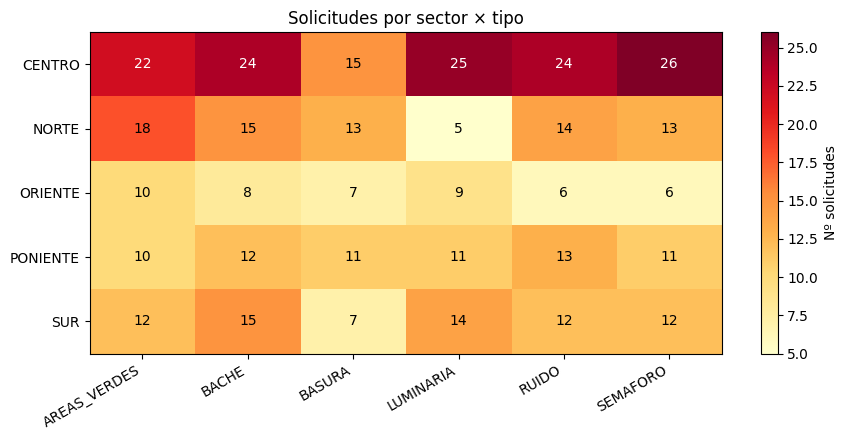

In [12]:
# Heatmap del cruce sector × tipo (sin la fila/col total)
data = cross.drop('TOTAL', axis=0).drop('TOTAL', axis=1)
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(data.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(data.columns)))
ax.set_xticklabels(data.columns, rotation=30, ha='right')
ax.set_yticks(range(len(data.index)))
ax.set_yticklabels(data.index)
for i in range(len(data.index)):
    for j in range(len(data.columns)):
        ax.text(j, i, data.values[i, j], ha='center', va='center',
                color='black' if data.values[i, j] < 20 else 'white', fontsize=10)
ax.set_title('Solicitudes por sector × tipo')
plt.colorbar(im, ax=ax, label='Nº solicitudes')
plt.tight_layout()
plt.show()

### 6.2 Ciudadanos reincidentes (≥ 5 solicitudes)
> *Responde a*: "Detectar perfiles de alta reincidencia"

El patrón inyectado en la generación nos da 5 ciudadanos claramente reincidentes — el modelo permite identificarlos sin asumir el conocimiento previo.

In [13]:
reinc = (df_solicitud
    .groupby('ciudadano_id')
    .agg(total=('solicitud_id','count'),
         tipos_distintos=('tipo_id','nunique'),
         primera=('fecha_creacion','min'),
         ultima=('fecha_creacion','max'))
    .query('total >= 5')
    .reset_index()
    .merge(df_ciudadano[['ciudadano_id','nombre','apellido']], on='ciudadano_id')
    .sort_values('total', ascending=False))
reinc['rango_dias'] = (reinc['ultima'] - reinc['primera']).dt.days
print(f"Ciudadanos reincidentes detectados: {len(reinc)}")
reinc[['ciudadano_id','nombre','apellido','total','tipos_distintos','rango_dias']].head(10)

Ciudadanos reincidentes detectados: 36


,ciudadano_id,nombre,apellido,total,tipos_distintos,rango_dias
0,1,Rafael,González,40,6,322
4,5,Emilia,Muñoz,35,6,283
1,2,Felipe,Araya,31,6,312
2,3,Edith,Concha,25,6,299
3,4,Noelia,Pérez,23,6,308
27,38,Alexis,Campos,12,4,287
21,30,Jorge,Vera,11,6,220
8,10,Freddy,González,9,5,283
33,46,Ana,Troncoso,9,5,227
24,35,Margarita,Sánchez,8,5,249


### 6.3 Tiempo promedio de resolución por unidad y tipo
> *Responde a*: "Reducir tiempos de respuesta"

Identifica dónde se concentran los cuellos de botella y por qué tipo de problema.

In [14]:
cerr = df_solicitud[df_solicitud['fecha_cierre'].notna()].copy()
cerr['horas'] = (cerr['fecha_cierre'] - cerr['fecha_creacion']).dt.total_seconds() / 3600

tiempo = (cerr
    .merge(df_unidad, on='unidad_id')
    .merge(df_tipo[['tipo_id','codigo','sla_horas']].rename(columns={'codigo':'tipo'}), on='tipo_id')
    .groupby(['nombre','tipo'])
    .agg(cerradas=('horas','count'),
         horas_prom=('horas','mean'),
         sla=('sla_horas','first'))
    .reset_index()
    .round({'horas_prom': 1}))
tiempo['vs_sla'] = (tiempo['horas_prom'] / tiempo['sla'] * 100).round(0).astype(int).astype(str) + '%'
tiempo.rename(columns={'nombre':'unidad'})

,unidad,tipo,cerradas,horas_prom,sla,vs_sla
0,Aseo y Ornato,AREAS_VERDES,52,171.5,240,71%
1,Aseo y Ornato,BASURA,44,57.6,72,80%
2,Dirección de Obras,BACHE,57,107.6,168,64%
3,Dirección de Obras,LUMINARIA,54,96.8,120,81%
4,Inspección,RUIDO,49,39.8,48,83%
5,Tránsito,SEMAFORO,53,30.5,24,127%


### 6.4 Cumplimiento de SLA por unidad
> *Responde a*: "Optimizar asignación de cuadrillas"

% de solicitudes cerradas que respetó el plazo Ley 19.880.

In [15]:
cerr['cumple_sla'] = cerr['fecha_cierre'] <= cerr['fecha_limite_respuesta']
sla_unidad = (cerr
    .merge(df_unidad, on='unidad_id')
    .groupby('codigo')
    .agg(total=('cumple_sla','count'),
         cumplidas=('cumple_sla','sum'))
    .reset_index())
sla_unidad['atrasadas'] = sla_unidad['total'] - sla_unidad['cumplidas']
sla_unidad['pct_cumplimiento'] = (100 * sla_unidad['cumplidas'] / sla_unidad['total']).round(1)
sla_unidad = sla_unidad.sort_values('pct_cumplimiento', ascending=False)
sla_unidad

,codigo,total,cumplidas,atrasadas,pct_cumplimiento
2,INSP,49,39,10,79.6
1,DOM,111,85,26,76.6
0,ASEO,96,72,24,75.0
3,TRAN,53,37,16,69.8


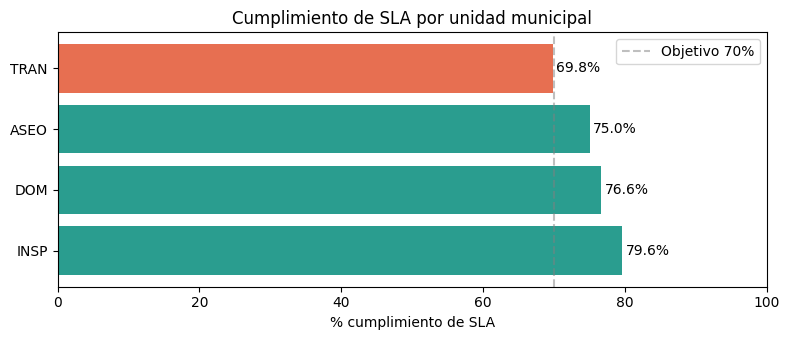

In [16]:
# Gráfico de barras horizontales — cumplimiento SLA
fig, ax = plt.subplots(figsize=(8, 3.5))
colores = ['#2A9D8F' if p >= 70 else '#E76F51' for p in sla_unidad['pct_cumplimiento']]
ax.barh(sla_unidad['codigo'], sla_unidad['pct_cumplimiento'], color=colores)
for i, (codigo, pct) in enumerate(zip(sla_unidad['codigo'], sla_unidad['pct_cumplimiento'])):
    ax.text(pct + 0.5, i, f'{pct}%', va='center', fontsize=10)
ax.axvline(70, color='gray', linestyle='--', alpha=0.5, label='Objetivo 70%')
ax.set_xlabel('% cumplimiento de SLA')
ax.set_title('Cumplimiento de SLA por unidad municipal')
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

### 6.5 Zonas críticas recurrentes
> *Responde a*: "Identificar zonas críticas recurrentes" (decisión estratégica)

Top sectores por volumen + tipo predominante de cada uno.

In [17]:
zonas = (df_solicitud
    .merge(df_sector, on='sector_id')
    .merge(df_tipo[['tipo_id','codigo']].rename(columns={'codigo':'tipo'}), on='tipo_id'))

ranking = zonas.groupby('nombre').size().reset_index(name='total').sort_values('total', ascending=False)

# Tipo predominante por sector
predominante = (zonas.groupby(['nombre','tipo'])
    .size().reset_index(name='n')
    .sort_values(['nombre','n'], ascending=[True, False])
    .drop_duplicates('nombre'))
ranking = ranking.merge(predominante[['nombre','tipo','n']], on='nombre')
ranking.columns = ['sector','total','tipo_predominante','n_del_tipo']
ranking['pct_global'] = (100 * ranking['total'] / ranking['total'].sum()).round(1)
ranking

,sector,total,tipo_predominante,n_del_tipo,pct_global
0,CENTRO,136,SEMAFORO,26,34.0
1,NORTE,78,AREAS_VERDES,18,19.5
2,SUR,72,BACHE,15,18.0
3,PONIENTE,68,RUIDO,13,17.0
4,ORIENTE,46,AREAS_VERDES,10,11.5


### 6.6 Distribución espacial de solicitudes (uso del JSONB)
> *Demuestra*: el modelo híbrido permite agregar tanto sobre columnas relacionales como sobre el JSONB.

Cada punto es una solicitud georeferenciada extraída del campo `metadatos -> geolocalizacion`.

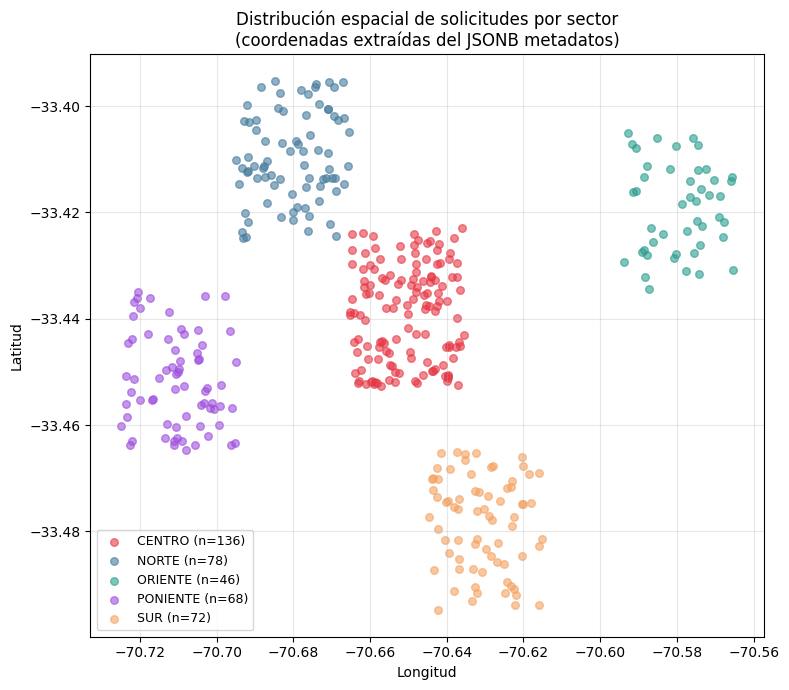

In [18]:
# Extraer lat/lon del JSONB (en el modelo real sería con jsonb operators ->>)
coords = pd.DataFrame([
    {'lat': s['metadatos']['geolocalizacion']['lat'],
     'lon': s['metadatos']['geolocalizacion']['lon'],
     'tipo': df_tipo.loc[df_tipo.tipo_id == s['tipo_id'], 'codigo'].iloc[0],
     'sector': df_sector.loc[df_sector.sector_id == s['sector_id'], 'nombre'].iloc[0]}
    for _, s in df_solicitud.iterrows()
])

fig, ax = plt.subplots(figsize=(8, 7))
colores_sector = {'CENTRO':'#E63946','NORTE':'#457B9D','SUR':'#F4A261',
                  'ORIENTE':'#2A9D8F','PONIENTE':'#9D4EDD'}
for sec, grupo in coords.groupby('sector'):
    ax.scatter(grupo['lon'], grupo['lat'], alpha=0.6, s=30,
               c=colores_sector[sec], label=f"{sec} (n={len(grupo)})")
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Distribución espacial de solicitudes por sector\n(coordenadas extraídas del JSONB metadatos)')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.7 Análisis del JSONB — profundidad de baches por sector
> *Demuestra*: extracción de atributos polimórficos desde el JSONB para análisis específico de un tipo.

Sólo solicitudes tipo BACHE — extraemos `metadatos -> atributos -> profundidad_cm`.

In [19]:
baches = df_solicitud[df_solicitud['tipo_id'] == 1].copy()
baches['profundidad'] = baches['metadatos'].apply(lambda m: m['atributos']['profundidad_cm'])
baches['ancho'] = baches['metadatos'].apply(lambda m: m['atributos']['ancho_cm'])
baches['calzada'] = baches['metadatos'].apply(lambda m: m['atributos']['calzada'])
baches = baches.merge(df_sector, on='sector_id')

resumen_baches = (baches.groupby('nombre')
    .agg(n=('solicitud_id','count'),
         prof_prom=('profundidad','mean'),
         prof_max=('profundidad','max'),
         ancho_prom=('ancho','mean'))
    .round(1)
    .sort_values('prof_prom', ascending=False)
    .reset_index())
resumen_baches.rename(columns={'nombre':'sector'})

,sector,n,prof_prom,prof_max,ancho_prom
0,SUR,15,17.3,30,111.7
1,NORTE,15,15.1,27,138.0
2,ORIENTE,8,14.6,29,104.6
3,PONIENTE,12,13.3,25,101.9
4,CENTRO,24,13.0,28,118.4


## 7. Validación del JSON Schema

Cargamos `JSON_Schema.json` y validamos los 400 registros de metadatos + 12 casos inválidos diseñados.

In [ ]:
# Cargar Schema desde el archivo de entrega
# Rutas portables: busca el JSON Schema en ubicaciones comunes
candidatos = [
    Path('JSON_Schema.json'),
    Path('../schema/JSON_Schema.json'),
    Path('../JSON_Schema.json'),
    Path('./schema/JSON_Schema.json'),
]
SCHEMA_PATH = next((p for p in candidatos if p.exists()), candidatos[0])

with open(SCHEMA_PATH) as f:
    schema = json.load(f)

Draft202012Validator.check_schema(schema)
validator = Draft202012Validator(schema, format_checker=FormatChecker())
print(f'Schema cargado desde {SCHEMA_PATH} (Draft 2020-12)')

In [21]:
# Validar los 400 metadatos sintéticos
def es_valido(r):
    try:
        validator.validate(r)
        return True
    except jsonschema.ValidationError:
        return False

validos = df_solicitud['metadatos'].apply(es_valido).sum()
print(f"Registros válidos contra el Schema: {validos}/{len(df_solicitud)} "
      f"({100*validos/len(df_solicitud):.1f}%)")

Registros válidos contra el Schema: 400/400 (100.0%)


In [22]:
# 12 casos inválidos diseñados a propósito
casos_inv = [
    ("falta geolocalizacion",
     {"canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"BACHE","profundidad_cm":10,"ancho_cm":50,"calzada":"ASFALTO"}}),
    ("lat fuera de rango Chile",
     {"geolocalizacion":{"lat":10.0,"lon":-70.6},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"BACHE","profundidad_cm":10,"ancho_cm":50,"calzada":"ASFALTO"}}),
    ("lon como string",
     {"geolocalizacion":{"lat":-33.4,"lon":"no-numero"},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"BACHE","profundidad_cm":10,"ancho_cm":50,"calzada":"ASFALTO"}}),
    ("ip formato inválido",
     {"geolocalizacion":{"lat":-33.4,"lon":-70.6},
      "canal_origen":{"ip":"no-es-ip","user_agent":"X"},
      "atributos":{"tipo":"BACHE","profundidad_cm":10,"ancho_cm":50,"calzada":"ASFALTO"}}),
    ("tipo fuera del enum",
     {"geolocalizacion":{"lat":-33.4,"lon":-70.6},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"ALIENIGENA"}}),
    ("BACHE con profundidad > 100",
     {"geolocalizacion":{"lat":-33.4,"lon":-70.6},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"BACHE","profundidad_cm":500,"ancho_cm":50,"calzada":"ASFALTO"}}),
    ("BACHE calzada fuera del enum",
     {"geolocalizacion":{"lat":-33.4,"lon":-70.6},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"BACHE","profundidad_cm":10,"ancho_cm":50,"calzada":"ADOQUIN"}}),
    ("BACHE con campo extra",
     {"geolocalizacion":{"lat":-33.4,"lon":-70.6},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"BACHE","profundidad_cm":10,"ancho_cm":50,"calzada":"ASFALTO","extra":"x"}}),
    ("LUMINARIA numero_poste mal formado",
     {"geolocalizacion":{"lat":-33.4,"lon":-70.6},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"LUMINARIA","numero_poste":"POSTE-X","tipo_falla":"APAGADA"}}),
    ("BASURA riesgo_sanitario no boolean",
     {"geolocalizacion":{"lat":-33.4,"lon":-70.6},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"BASURA","volumen_estimado_m3":2.5,"riesgo_sanitario":"si"}}),
    ("Mezcla tipo=BACHE con campos de LUMINARIA",
     {"geolocalizacion":{"lat":-33.4,"lon":-70.6},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X"},
      "atributos":{"tipo":"BACHE","numero_poste":"P-1234","tipo_falla":"APAGADA"}}),
    ("version_app no semver",
     {"geolocalizacion":{"lat":-33.4,"lon":-70.6},
      "canal_origen":{"ip":"200.1.2.3","user_agent":"X","version_app":"v2"},
      "atributos":{"tipo":"RUIDO","horario":"DIURNO","fuente_presunta":"VIVIENDA"}}),
]

resultados = []
for desc, registro in casos_inv:
    rechazado = not es_valido(registro)
    resultados.append({'caso': desc, 'rechazado': '✅' if rechazado else '❌'})

pd.DataFrame(resultados)

,caso,rechazado
0,falta geolocalizacion,✅
1,lat fuera de rango Chile,✅
2,lon como string,✅
3,ip formato inválido,✅
4,tipo fuera del enum,✅
5,BACHE con profundidad > 100,✅
6,BACHE calzada fuera del enum,✅
7,BACHE con campo extra,✅
8,LUMINARIA numero_poste mal formado,✅
9,BASURA riesgo_sanitario no boolean,✅


## 8. Evaluación crítica de resultados

### 8.1 Fortalezas del modelo

- **Integridad demostrada**: 20 pruebas negativas SQL + 5 invariantes pandas + 12 casos JSON Schema = 37 puntos de control automatizados.
- **Trazabilidad regulatoria**: `historial_estado` permite reconstruir cualquier solicitud y cumplir con requerimientos de la Ley 19.880.
- **Modelo híbrido genuinamente útil**: el JSONB no es decorativo — la consulta 6.7 (profundidad de baches por sector) sería imposible o muy costosa con columnas nullables por tipo.
- **Validación bidireccional del JSONB**: el JSON Schema en aplicación + CHECK en BD garantizan que los datos nunca entran corruptos.
- **Patrones analíticos verificables**: los datos sintéticos contienen patrones conocidos (reincidencia, concentración, retraso) que las consultas detectan correctamente — eso valida la utilidad del modelo, no solo su corrección.

### 8.2 Limitaciones identificadas

- **Denormalización controlada**: `estado_actual_id` en `solicitud` es redundante respecto al historial. Sin trigger de sincronización, podrían divergir. En implementación real se debe agregar trigger `AFTER INSERT ON historial_estado`.
- **Rigidez relacional**: agregar un nuevo tipo de solicitud (ej. "PERROS_VAGOS") requiere modificar el JSON Schema. No es un cambio trivial.
- **Adjuntos sin verificación**: el URI es una `TEXT` sin validar — un puntero roto a S3 no se detecta a nivel BD.
- **Sin particionado**: con 150k solicitudes/año estimadas, en 3 años hay ~450k filas. Aún es manejable pero se vería favorecido particionando `solicitud` por año.

### 8.3 Oportunidades de mejora

1. **Trigger de sincronización** entre `historial_estado` y `solicitud.estado_actual_id`.
2. **Índice GIN especializado** sobre `metadatos -> 'atributos' ->> 'tipo'` para acelerar análisis por tipo dentro del JSONB.
3. **PostGIS** sobre coordenadas para clustering geográfico nativo de zonas críticas (hoy hecho por sector, mejorable a polígonos reales).
4. **Modelo predictivo** sobre el dataset: clasificador binario `va_a_retrasarse(solicitud) → {sí, no}` usando como features tipo, prioridad, canal, hora, día de semana, sector. Es la Opción A del enunciado, complementaria al JSON Schema ya entregado.
5. **Particionado por `fecha_creacion`** cuando el volumen supere ~500k filas.

### 8.4 Buenas prácticas aplicadas

- **Diccionario de datos formal** (`Diccionario_Datos.xlsx` con 83 columnas + 23 campos JSONB documentados).
- **Documentación inline** vía `COMMENT ON` en SQL para cada tabla y columna crítica.
- **Validaciones automatizadas y reproducibles**: 4 archivos SQL ejecutables + 1 validador Python.
- **Determinismo**: seed fija (42) en el generador → resultados reproducibles entre ejecuciones.
- **Separación de responsabilidades**: catálogos, operativas, negocio, trazabilidad cada uno en su grupo lógico.
- **Cumplimiento normativo**: Ley 21.719 (`consentimiento_datos`, `fecha_consentimiento`), Ley 19.880 (SLA explícito en `tipo_solicitud.sla_horas`), Ley 20.285 (datos agregados publicables).
